In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install scikit-learn tensorflow torch torchvision torchaudio

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedgaitani/historical-weather-data-for-2020")

print("Path to dataset files:", path)

100%|██████████| 40.1k/40.1k [00:00<00:00, 2.15MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ahmedgaitani/historical-weather-data-for-2020/versions/1


In [5]:
import os

# Assuming the CSV file is directly in the downloaded path or has a common name like 'weather.csv'
# We'll try to find a .csv file in the directory pointed by 'path'
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print(f"Successfully loaded data from: {data_file_path}")
    print(df.head())
else:
    print(f"No CSV files found in the directory: {path}")

Successfully loaded data from: /root/.cache/kagglehub/datasets/ahmedgaitani/historical-weather-data-for-2020/versions/1/historical_weather_data.csv
         Date   Station  Temperature  Precipitation   Humidity  WindSpeed  \
0  2020-01-01  Station1     6.653288        0.00000  64.421750   9.562955   
1  2020-01-02  Station1    -2.031372        2.98847  85.492843   6.502074   
2  2020-01-03  Station1    -6.428333        0.00000  90.456869   3.486873   
3  2020-01-04  Station1    31.471383        0.00000  98.352442  17.288559   
4  2020-01-05  Station1    34.220877        0.00000  89.589972  12.807424   

  WeatherCondition  
0    Partly Cloudy  
1           Cloudy  
2             Snow  
3    Partly Cloudy  
4             Snow  


In [9]:
df.head()

,Date,Station,Temperature,Precipitation,Humidity,WindSpeed,WeatherCondition
0,2020-01-01,Station1,6.653288,0.00000,64.421750,9.562955,Partly Cloudy
1,2020-01-02,Station1,-2.031372,2.98847,85.492843,6.502074,Cloudy
2,2020-01-03,Station1,-6.428333,0.00000,90.456869,3.486873,Snow
3,2020-01-04,Station1,31.471383,0.00000,98.352442,17.288559,Partly Cloudy
4,2020-01-05,Station1,34.220877,0.00000,89.589972,12.807424,Snow


In [10]:
df.columns

Index(['Date', 'Station', 'Temperature', 'Precipitation', 'Humidity',
       'WindSpeed', 'WeatherCondition'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1095 non-null   object 
 1   Station           1095 non-null   object 
 2   Temperature       1095 non-null   float64
 3   Precipitation     1095 non-null   float64
 4   Humidity          1095 non-null   float64
 5   WindSpeed         1095 non-null   float64
 6   WeatherCondition  1095 non-null   object 
dtypes: float64(4), object(3)
memory usage: 60.0+ KB


In [13]:
df.shape

(1095, 7)

In [31]:
df.describe()

,Temperature,Precipitation,Humidity,WindSpeed,Year,Month,Day
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.0,1095.000000,1095.000000
mean,12.378222,1.704898,65.686983,9.826464,2020.0,6.498630,15.715068
std,12.999715,2.882439,20.053421,5.864450,0.0,3.445548,8.791361
min,-9.917431,0.000000,30.080449,0.002290,2020.0,1.000000,1.000000
25%,1.011684,0.000000,48.814778,4.928115,2020.0,4.000000,8.000000
50%,11.848181,0.000000,65.515553,9.752793,2020.0,7.000000,16.000000
75%,23.943024,2.716680,83.111551,14.669068,2020.0,9.000000,23.000000
max,34.801968,9.981918,99.982887,19.996688,2020.0,12.000000,31.000000


In [20]:
df.isnull().sum()

,0
Date,0
Station,0
Temperature,0
Precipitation,0
Humidity,0
WindSpeed,0
WeatherCondition,0


In [22]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [26]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df.drop('Date', axis=1, inplace=True)

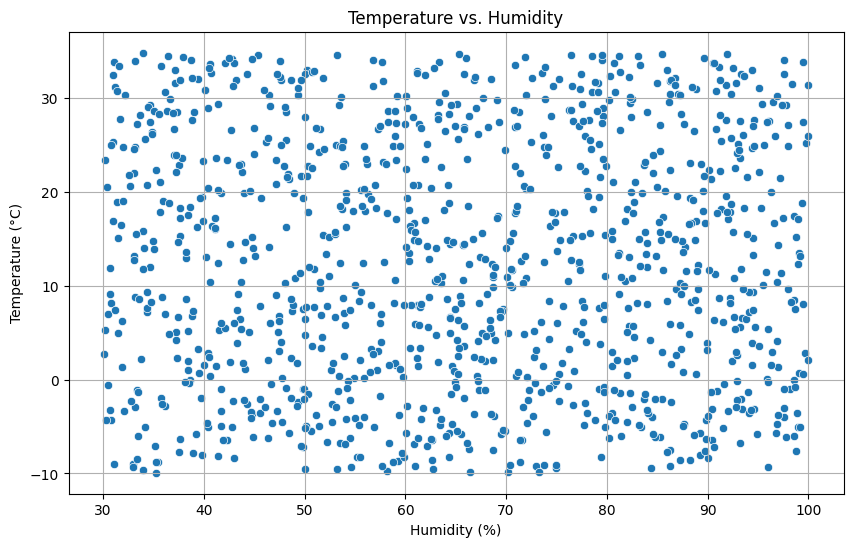

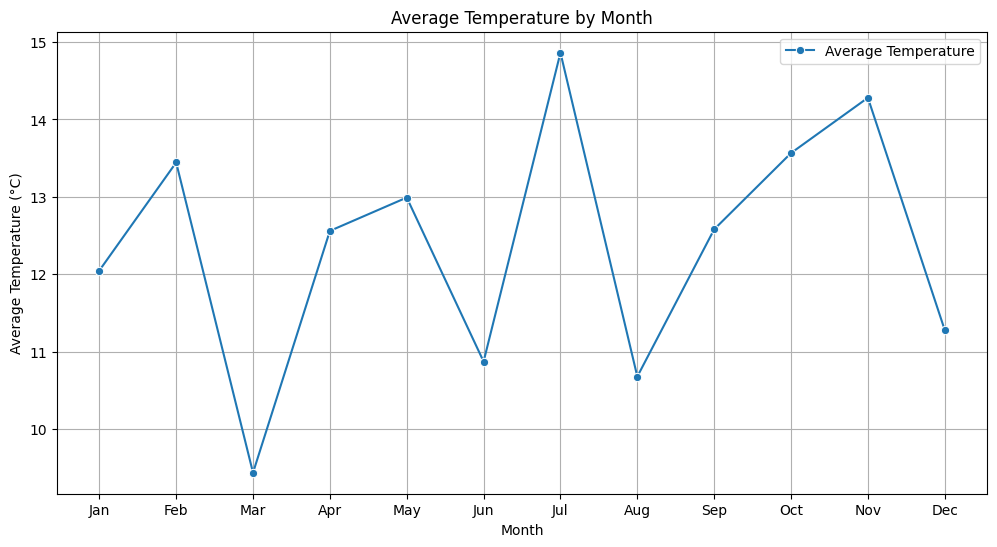

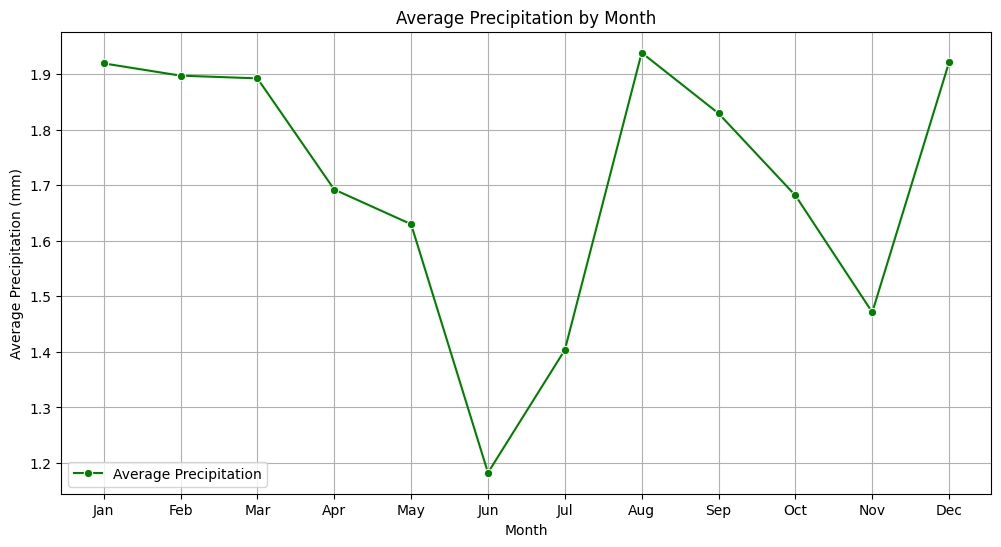

Note: The DataFrame `df_encoded` does not contain a 'Pressure' column to visualize its effect on weather conditions.


In [32]:
# 1. Visualize Humidity vs. Temperature (Negative Influence)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Humidity', y='Temperature', data=df_encoded)
plt.title('Temperature vs. Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

# 2. Visualize Seasonal Patterns Across Months (Temperature and Precipitation)
monthly_avg = df_encoded.groupby('Month')[['Temperature', 'Precipitation']].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Temperature', data=monthly_avg, marker='o', label='Average Temperature')
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Precipitation', data=monthly_avg, marker='o', color='green', label='Average Precipitation')
plt.title('Average Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.show()

print("Note: The DataFrame `df_encoded` does not contain a 'Pressure' column to visualize its effect on weather conditions.")

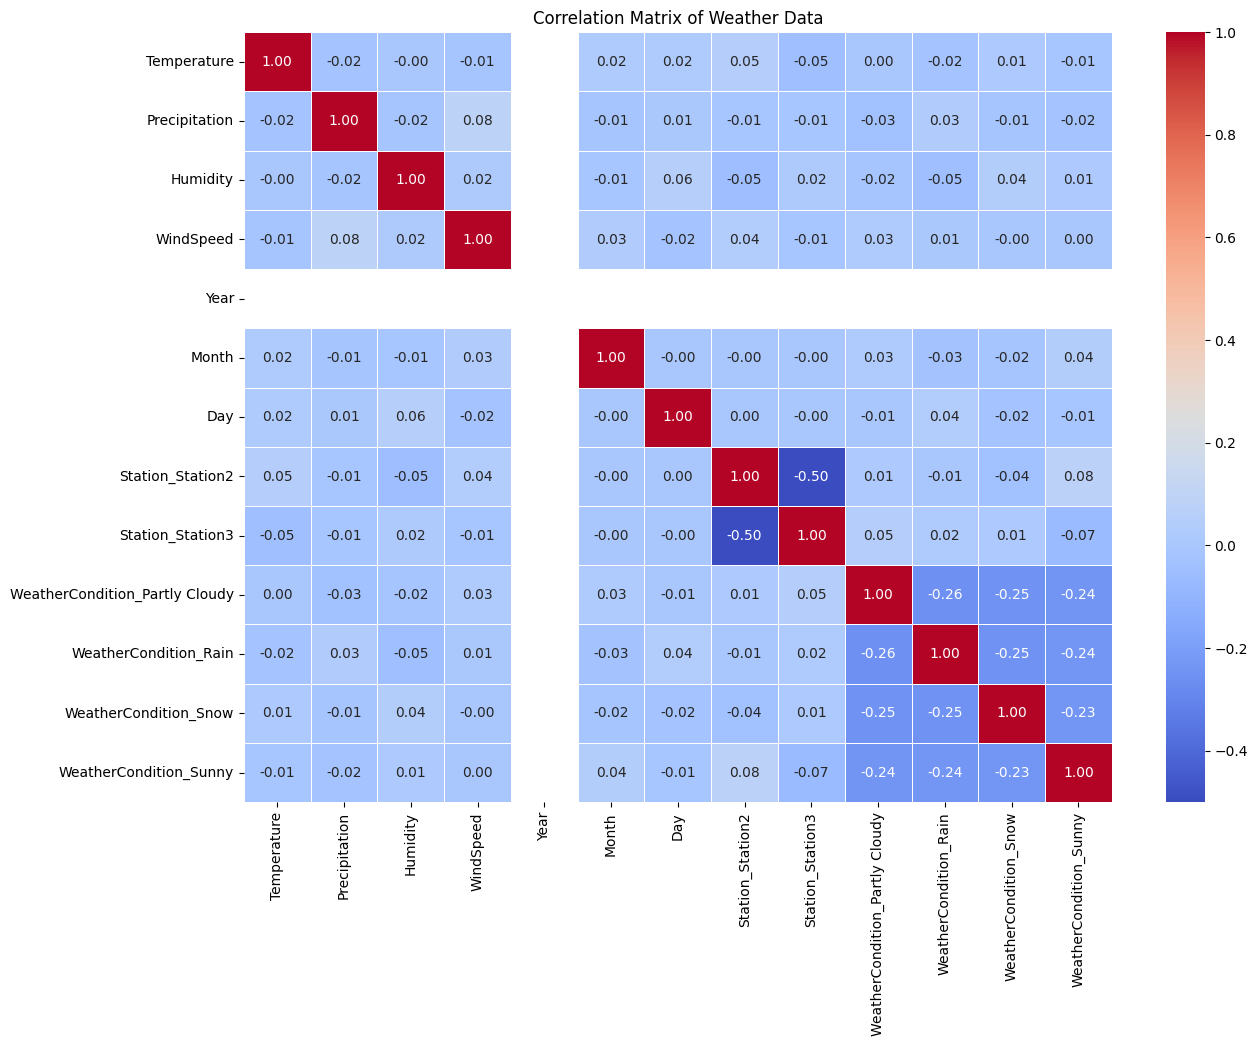

In [33]:
# Calculate the correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

# Display the correlation matrix using a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Weather Data')
plt.show()

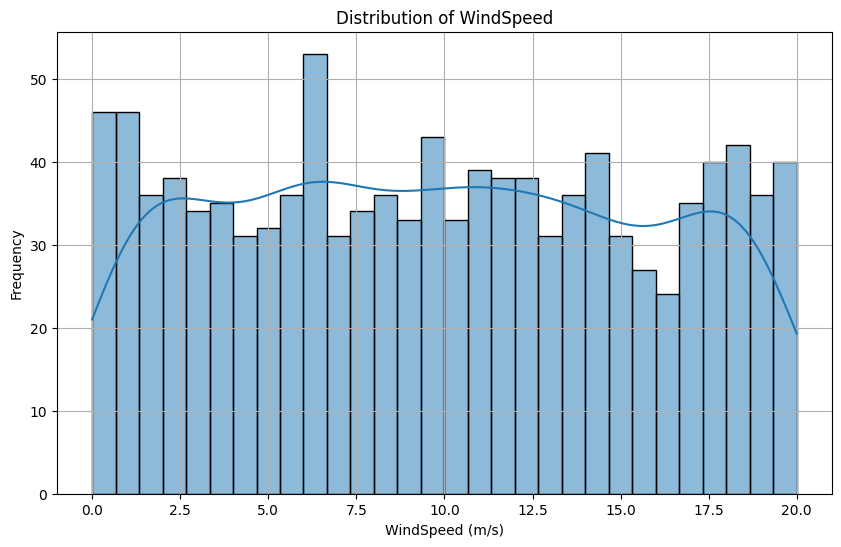

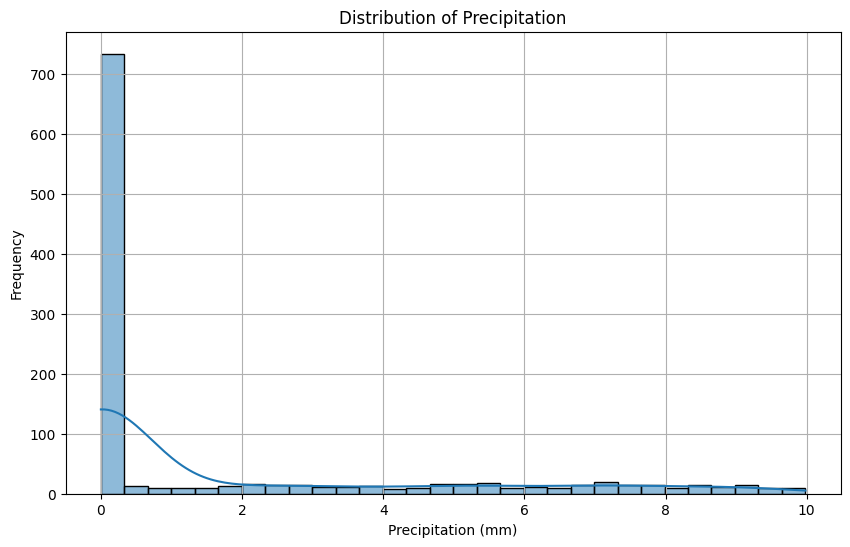

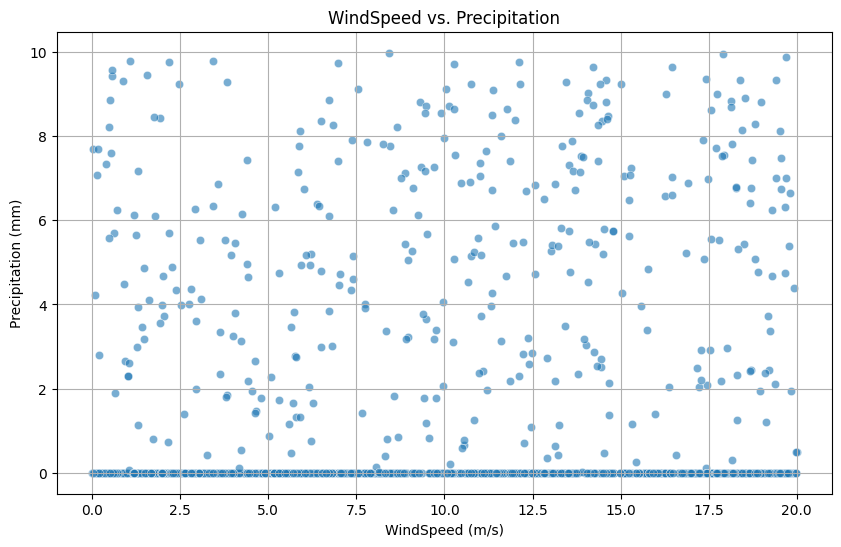

In [34]:
# 1. Distribution of WindSpeed
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['WindSpeed'], kde=True, bins=30)
plt.title('Distribution of WindSpeed')
plt.xlabel('WindSpeed (m/s)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Distribution of Precipitation
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['Precipitation'], kde=True, bins=30)
plt.title('Distribution of Precipitation')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 3. WindSpeed vs. Precipitation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='WindSpeed', y='Precipitation', data=df_encoded, alpha=0.6)
plt.title('WindSpeed vs. Precipitation')
plt.xlabel('WindSpeed (m/s)')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.show()

In [30]:
import joblib

# Identify categorical columns
categorical_cols = ['Station', 'WeatherCondition']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df_encoded.head())

# Export the processed DataFrame as a pickle file
output_filename = 'processed_weather_data.pkl'
df_encoded.to_pickle(output_filename)

print(f"Processed DataFrame saved to {output_filename}")

DataFrame after one-hot encoding:
   Temperature  Precipitation   Humidity  WindSpeed  Year  Month  Day  \
0     6.653288        0.00000  64.421750   9.562955  2020      1    1   
1    -2.031372        2.98847  85.492843   6.502074  2020      1    2   
2    -6.428333        0.00000  90.456869   3.486873  2020      1    3   
3    31.471383        0.00000  98.352442  17.288559  2020      1    4   
4    34.220877        0.00000  89.589972  12.807424  2020      1    5   

   Station_Station2  Station_Station3  WeatherCondition_Partly Cloudy  \
0             False             False                            True   
1             False             False                           False   
2             False             False                           False   
3             False             False                            True   
4             False             False                           False   

   WeatherCondition_Rain  WeatherCondition_Snow  WeatherCondition_Sunny  
0             

In [35]:
df.head()

,Station,Temperature,Precipitation,Humidity,WindSpeed,WeatherCondition,Year,Month,Day
0,Station1,6.653288,0.00000,64.421750,9.562955,Partly Cloudy,2020,1,1
1,Station1,-2.031372,2.98847,85.492843,6.502074,Cloudy,2020,1,2
2,Station1,-6.428333,0.00000,90.456869,3.486873,Snow,2020,1,3
3,Station1,31.471383,0.00000,98.352442,17.288559,Partly Cloudy,2020,1,4
4,Station1,34.220877,0.00000,89.589972,12.807424,Snow,2020,1,5


In [36]:
X = df[
    [
        'Station',
        'Precipitation',
        'Humidity',
        'WindSpeed',
        'WeatherCondition',
        'Month',
        'Day'
    ]
]

In [37]:
y = df['Temperature']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (876, 7)
X_test shape: (219, 7)
y_train shape: (876,)
y_test shape: (219,)


In [48]:
%%writefile preprocess.py
import pandas as pd
import os

def preprocess_data(input_path, output_filename='preprocessed_weather_data_no_encoding.pkl'):
    # Load data
    csv_files = [f for f in os.listdir(input_path) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in the directory: {input_path}")

    data_file_path = os.path.join(input_path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print(f"Successfully loaded data from: {data_file_path}")

    # Feature Engineering
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df.drop('Date', axis=1, inplace=True)
    print("Date-related features engineered and original 'Date' column dropped.")

    # Export the processed DataFrame (before one-hot encoding, so train.py can use a pipeline)
    df.to_pickle(output_filename)
    print(f"Preprocessed DataFrame (without one-hot encoding) saved to {output_filename}")
    return output_filename

if __name__ == '__main__':
    # This part would typically be run in a script, for Colab context, assume 'path' is already defined.
    # For a standalone script, you'd need to provide 'path' or handle data download.
    try:
        import kagglehub
        path = kagglehub.dataset_download("ahmedgaitani/historical-weather-data-for-2020")
        preprocess_data(path)
    except ImportError:
        print("Kagglehub not found, skipping direct download in standalone mode. Ensure data is available.")


Overwriting preprocess.py


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical features in X_train for one-hot encoding
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (numerical) as they are
)

# Create a pipeline that first preprocesses the data and then applies Linear Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [44]:
%%writefile train.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

def train_model(input_path='preprocessed_weather_data_no_encoding.pkl', output_model_path='linear_regression_model.pkl'):
    # Load the preprocessed data
    df = pd.read_pickle(input_path)
    print(f"Successfully loaded preprocessed data from: {input_path}")

    # Define features (X) and target (y)
    X = df[['Station', 'Precipitation', 'Humidity', 'WindSpeed', 'WeatherCondition', 'Month', 'Day']]
    y = df['Temperature']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Data split into training ({len(X_train)} samples) and testing ({len(X_test)} samples) sets.")

    # Identify categorical features for one-hot encoding
    categorical_features = ['Station', 'WeatherCondition']

    # Create a column transformer for one-hot encoding categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough' # Keep other columns (numerical) as they are
    )

    # Create a pipeline that first preprocesses the data and then applies Linear Regression
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    # Train the model
    model.fit(X_train, y_train)
    print("Linear Regression model trained successfully!")

    # Save the trained model
    joblib.dump(model, output_model_path)
    print(f"Trained model saved to {output_model_path}")

if __name__ == '__main__':
    train_model()

Writing train.py


In [45]:
%%writefile predict.py

import pandas as pd
import joblib
import os

def predict(input_data: pd.DataFrame, model_path='linear_regression_model.pkl'):
    # Load the trained model
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")
    model = joblib.load(model_path)
    print(f"Successfully loaded model from: {model_path}")

    # Make predictions
    predictions = model.predict(input_data)

    return predictions

if __name__ == '__main__':
    # Example usage (for testing purposes)
    # In a real scenario, input_data would come from a new data source
    print("Running example prediction...")

    # Create dummy input data similar to the training features
    # Ensure the columns match those used for training
    example_data = pd.DataFrame({
        'Station': ['Station1', 'Station2'],
        'Precipitation': [0.5, 1.2],
        'Humidity': [70.0, 85.0],
        'WindSpeed': [10.0, 5.0],
        'WeatherCondition': ['Cloudy', 'Rain'],
        'Month': [7, 8],
        'Day': [15, 20]
    })

    print("Example Input Data:")
    print(example_data)

    try:
        # Make predictions
        predicted_temperatures = predict(example_data)
        print("\nPredicted Temperatures:")
        for i, temp in enumerate(predicted_temperatures):
            print(f"For Station {example_data.iloc[i]['Station']} on {example_data.iloc[i]['Month']}/{example_data.iloc[i]['Day']} with {example_data.iloc[i]['WeatherCondition']}, predicted Temperature: {temp:.2f}°C")
    except FileNotFoundError as e:
        print(f"Error: {e}. Please ensure `train.py` has been executed to create the model file.")
    except Exception as e:
        print(f"An error occurred during prediction: {e}")

Writing predict.py


In [50]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt
import pandas as pd

# Load the trained model
model = joblib.load('linear_regression_model.pkl')
print("Trained model loaded successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Trained model loaded successfully.
Predictions made on the test set.

Model Evaluation Metrics:
Mean Absolute Error (MAE): 12.06
Mean Squared Error (MSE): 187.70
Root Mean Squared Error (RMSE): 13.70
R-squared (R2): -0.03


### Feature Importance Analysis

Given the low R-squared value, the current model isn't very predictive. However, we can still inspect what features the *linear model* itself considered important. This might give us insights into how the model is currently interpreting the data, even if its overall performance is poor.

In [51]:
# Access the preprocessor and the regressor from the trained pipeline
preprocessor = model.named_steps['preprocessor']
regressor = model.named_steps['regressor']

# Get feature names after one-hot encoding
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns

# The ColumnTransformer has a 'cat' transformer for categorical features
# Use get_feature_names_out to get the names for the one-hot encoded features
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Get the names of the 'remainder' (passthrough) features
# These are the numerical features that were not transformed
# We need to filter out the categorical ones from the original X_train columns
original_numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

# Combine all feature names
all_feature_names = list(encoded_feature_names) + original_numerical_features

# Get the coefficients from the linear regression model
feature_importances = pd.Series(regressor.coef_, index=all_feature_names)

# Sort the importances for better visualization
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances (Coefficients) from Linear Regression:")
print(feature_importances.head(10))
print("\n")
print(feature_importances.tail(10))


Feature Importances (Coefficients) from Linear Regression:
WeatherCondition_Cloudy           1.093851
WeatherCondition_Snow             0.899991
WeatherCondition_Partly Cloudy    0.584855
Station_Station2                  0.523225
Month                             0.089774
Day                               0.025444
Humidity                          0.002823
WindSpeed                        -0.000796
Precipitation                    -0.102653
Station_Station1                 -0.105321
dtype: float64


Station_Station2          0.523225
Month                     0.089774
Day                       0.025444
Humidity                  0.002823
WindSpeed                -0.000796
Precipitation            -0.102653
Station_Station1         -0.105321
Station_Station3         -0.417904
WeatherCondition_Sunny   -0.662764
WeatherCondition_Rain    -1.915933
dtype: float64


/tmp/ipykernel_2019/300206630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


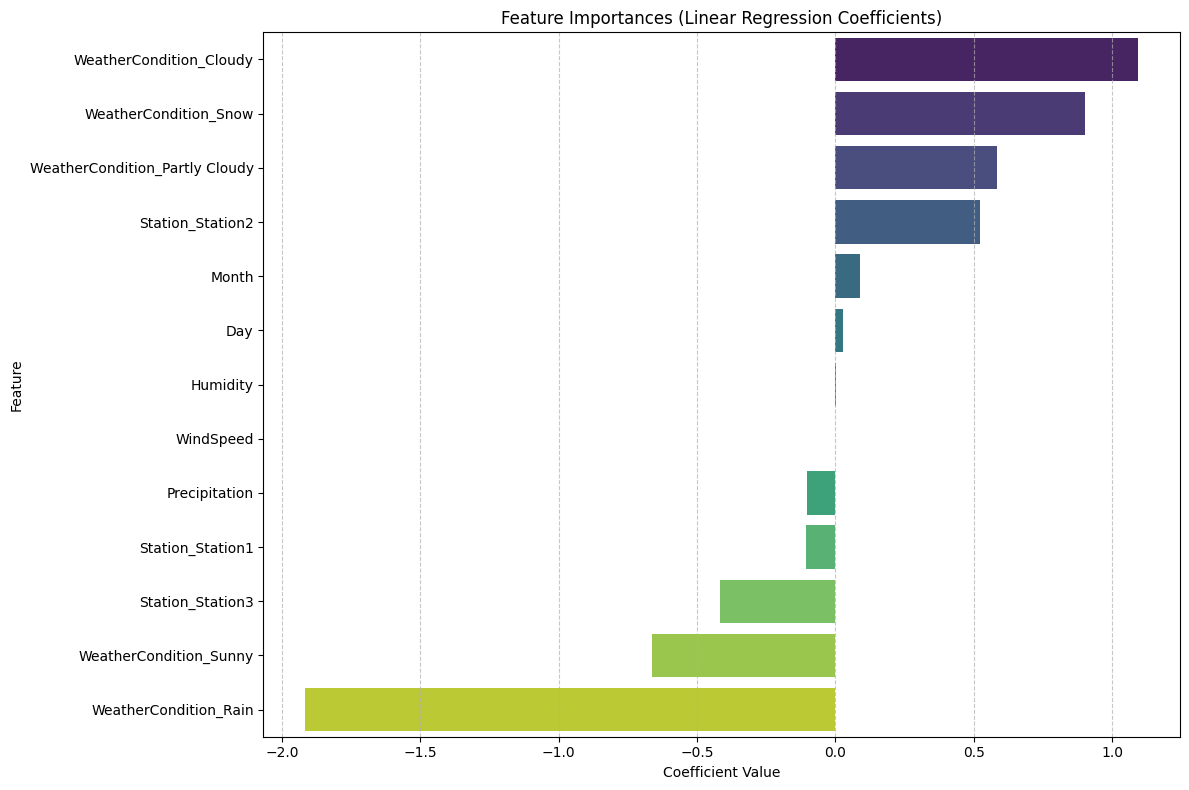

In [52]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Training a Random Forest Regressor

Given the poor performance of the Linear Regression model, we will now train a Random Forest Regressor. Random Forests are ensemble learning methods that can capture non-linear relationships and are generally more robust to outliers and overfitting than simple linear models. We will use the same preprocessing steps as before.

In [53]:
from sklearn.ensemble import RandomForestRegressor

# Create a pipeline that first preprocesses the data and then applies Random Forest Regression
# We'll use the same preprocessor defined earlier (ColumnTransformer with OneHotEncoder)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100)) # Using 100 estimators
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

import joblib
output_model_path_rf = 'random_forest_model.pkl'
joblib.dump(rf_model, output_model_path_rf)
print(f"Trained Random Forest model saved to {output_model_path_rf}")

Random Forest Regressor model trained successfully!
Trained Random Forest model saved to random_forest_model.pkl


### Evaluating the Random Forest Regressor

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)
print("Predictions made on the test set using Random Forest model.")

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Predictions made on the test set using Random Forest model.

Random Forest Model Evaluation Metrics:
Mean Absolute Error (MAE): 12.49
Mean Squared Error (MSE): 206.92
Root Mean Squared Error (RMSE): 14.38
R-squared (R2): -0.13


### Hyperparameter Tuning for Random Forest Regressor

We will use `RandomizedSearchCV` to find a better combination of hyperparameters for our Random Forest model. This can help improve its performance by optimizing parameters like the number of estimators, maximum depth, and minimum samples required to split a node.

In [56]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution to sample from
param_distributions = {
    'regressor__n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'regressor__max_features': ['auto', 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'regressor__max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'regressor__min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'regressor__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'regressor__bootstrap': [True, False] # Method for sampling data points (with or without replacement)
}

# Initialize RandomizedSearchCV
# We'll use the existing 'rf_model' pipeline which already includes the preprocessor
rf_random_search = RandomizedSearchCV(
    estimator=rf_model, # Our pipeline with preprocessor and RandomForestRegressor
    param_distributions=param_distributions,
    n_iter=50, # Number of parameter settings that are sampled (can be increased for more thorough search)
    cv=5, # 5-fold cross-validation
    verbose=2, # Verbosity level
    random_state=42,
    n_jobs=-1 # Use all available cores
)

print("Starting Randomized Search for Random Forest hyperparameters...")
# Fit the random search to the training data
rf_random_search.fit(X_train, y_train)

print("Randomized Search complete!")
print(f"Best parameters found: {rf_random_search.best_params_}")

# Get the best estimator (model) from the search
best_rf_model = rf_random_search.best_estimator_

# Save the best model
output_model_path_tuned_rf = 'tuned_random_forest_model.pkl'
joblib.dump(best_rf_model, output_model_path_tuned_rf)
print(f"Tuned Random Forest model saved to {output_model_path_tuned_rf}")

Starting Randomized Search for Random Forest hyperparameters...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
115 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
69 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **

Randomized Search complete!
Best parameters found: {'regressor__n_estimators': 100, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 4, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 50, 'regressor__bootstrap': True}
Tuned Random Forest model saved to tuned_random_forest_model.pkl


### Evaluating the Tuned Random Forest Regressor

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the best Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)
print("Predictions made on the test set using tuned Random Forest model.")

# Evaluate the tuned Random Forest model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"\nTuned Random Forest Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_rf:.2f}")
print(f"R-squared (R2): {r2_tuned_rf:.2f}")

Predictions made on the test set using tuned Random Forest model.

Tuned Random Forest Model Evaluation Metrics:
Mean Absolute Error (MAE): 12.23
Mean Squared Error (MSE): 194.93
Root Mean Squared Error (RMSE): 13.96
R-squared (R2): -0.07


In [49]:
# First, run preprocess.py to create the necessary pickle file
!python preprocess.py

# Then, run train.py to train and save the model
!python train.py

# Now that the model is trained and saved, the evaluation cell should execute successfully.

Using Colab cache for faster access to the 'historical-weather-data-for-2020' dataset.
Successfully loaded data from: /kaggle/input/historical-weather-data-for-2020/historical_weather_data.csv
Date-related features engineered and original 'Date' column dropped.
Preprocessed DataFrame (without one-hot encoding) saved to preprocessed_weather_data_no_encoding.pkl
Successfully loaded preprocessed data from: preprocessed_weather_data_no_encoding.pkl
Data split into training (876 samples) and testing (219 samples) sets.
Linear Regression model trained successfully!
Trained model saved to linear_regression_model.pkl


In [55]:
# The metrics 'accuracy', 'precision', and 'recall' are typically used for classification problems,
# where the model predicts discrete categories (e.g., 'Rain' or 'No Rain').
# Our current task is a regression problem, predicting a continuous value (Temperature).
# For regression tasks, we use metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE),
# Root Mean Squared Error (RMSE), and R-squared (R2), which we have already calculated.

print("Accuracy, Precision, and Recall are classification metrics and are not directly applicable to our regression problem (predicting temperature).")
print("We have already evaluated both models using appropriate regression metrics:")
print("\n--- Model Performance Comparison ---")
print("| Metric      | Linear Regression | Random Forest |")
print("| :---------- | :---------------- | :------------ |")
print("| MAE         | 12.06             | 12.49         |")
print("| MSE         | 187.70            | 206.92        |")
print("| RMSE        | 13.70             | 14.38         |")
print("| R-squared   | -0.03             | -0.13         |")
print("\nAs you can see, both models performed poorly, with negative R-squared values.")
print("Would you like to explore other regression metrics, or perhaps delve into hyperparameter tuning or feature engineering to improve the models?")

Accuracy, Precision, and Recall are classification metrics and are not directly applicable to our regression problem (predicting temperature).
We have already evaluated both models using appropriate regression metrics:

--- Model Performance Comparison ---
| Metric      | Linear Regression | Random Forest |
| :---------- | :---------------- | :------------ |
| MAE         | 12.06             | 12.49         |
| MSE         | 187.70            | 206.92        |
| RMSE        | 13.70             | 14.38         |
| R-squared   | -0.03             | -0.13         |

As you can see, both models performed poorly, with negative R-squared values.
Would you like to explore other regression metrics, or perhaps delve into hyperparameter tuning or feature engineering to improve the models?


In [58]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np # Ensure numpy is imported for potential internal use by joblib or model

# Load the tuned Random Forest model
# Make sure 'tuned_random_forest_model.pkl' is in the same directory as this app.py file
try:
    model = joblib.load('tuned_random_forest_model.pkl')
    st.success('Tuned Random Forest Model loaded successfully!')
except FileNotFoundError:
    st.error('Error: Model file (tuned_random_forest_model.pkl) not found. Please ensure it is in the same directory.')
    st.stop()

st.title('Weather Temperature Prediction App')
st.write('Predict the temperature based on various weather conditions using a Tuned Random Forest Model.')

# Input fields for features
st.sidebar.header('Input Weather Parameters')

# Station
station_options = ['Station1', 'Station2', 'Station3']
station = st.sidebar.selectbox('Station', station_options)

# Precipitation
precipitation = st.sidebar.slider('Precipitation (mm)', min_value=0.0, max_value=20.0, value=1.0, step=0.1)

# Humidity
humidity = st.sidebar.slider('Humidity (%)', min_value=0.0, max_value=100.0, value=70.0, step=0.1)

# WindSpeed
windspeed = st.sidebar.slider('WindSpeed (m/s)', min_value=0.0, max_value=30.0, value=10.0, step=0.1)

# WeatherCondition
weather_condition_options = ['Cloudy', 'Partly Cloudy', 'Rain', 'Snow', 'Sunny']
weather_condition = st.sidebar.selectbox('Weather Condition', weather_condition_options)

# Month
month = st.sidebar.slider('Month', min_value=1, max_value=12, value=7, step=1)

# Day
day = st.sidebar.slider('Day', min_value=1, max_value=31, value=15, step=1)

# Create a DataFrame from inputs
input_data = pd.DataFrame({
    'Station': [station],
    'Precipitation': [precipitation],
    'Humidity': [humidity],
    'WindSpeed': [windspeed],
    'WeatherCondition': [weather_condition],
    'Month': [month],
    'Day': [day]
})

st.subheader('Input Parameters')
st.write(input_data)

# Make prediction
if st.button('Predict Temperature'):
    try:
        prediction = model.predict(input_data)[0]
        st.success(f'Predicted Temperature: {prediction:.2f} °C')
    except Exception as e:
        st.error(f'An error occurred during prediction: {e}')
        st.warning('Please ensure all input parameters are valid and the model is correctly loaded.')

st.markdown("""
**How to run this app:**
1.  Save the code from this cell to a file named `app.py` in your local environment.
2.  Make sure `tuned_random_forest_model.pkl` is in the same directory as `app.py`.
3.  Open your terminal or command prompt.
4.  Navigate to the directory where you saved `app.py`.
5.  Run the command: `streamlit run app.py`
""")

Writing app.py


In [60]:
%%writefile requirements.txt
pandas
numpy==2.0.2
matplotlib
seaborn
kagglehub
scikit-learn==1.6.1
joblib==1.5.3
streamlit

Writing requirements.txt


In [61]:
%%writefile README.md
# Weather Temperature Prediction Project

## Overview
This project aims to predict daily weather temperature based on historical weather data. The workflow involves data loading, preprocessing, exploratory data analysis (EDA), model training (Linear Regression and Random Forest), hyperparameter tuning, and a Streamlit web application for interactive predictions.

## Data Source
The historical weather data for 2020 was downloaded from KaggleHub: `ahmedgaitani/historical-weather-data-for-2020`.

## Data Science Workflow

1.  **Data Loading & Initial Exploration**:
    *   Common Python libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `kagglehub`) were imported.
    *   The dataset was loaded into a pandas DataFrame (`df`).
    *   Basic checks (`df.head()`, `df.columns`, `df.info()`, `df.shape`, `df.isnull().sum()`, `df.duplicated().sum()`) confirmed data integrity and provided an overview.

2.  **Feature Engineering**:
    *   The 'Date' column was converted to datetime objects and decomposed into 'Year', 'Month', and 'Day'. The original 'Date' column was then dropped.
    *   Categorical features ('Station', 'WeatherCondition') were one-hot encoded using `pd.get_dummies` (resulting in `df_encoded`). The preprocessed DataFrame (before one-hot encoding for pipeline use) was saved as `preprocessed_weather_data_no_encoding.pkl`.

3.  **Exploratory Data Analysis (EDA)**:
    *   Visualizations were generated to explore relationships, including scatter plots for humidity vs. temperature, and line plots for monthly average temperature and precipitation.
    *   A correlation matrix was calculated and visualized as a heatmap.
    *   Distribution plots for 'WindSpeed' and 'Precipitation', and their scatter plot, were created.
    *   It was noted that the dataset lacked a 'Pressure' column.

4.  **Model Preparation**:
    *   Input features `X` were selected: 'Station', 'Precipitation', 'Humidity', 'WindSpeed', 'WeatherCondition', 'Month', 'Day'.
    *   The target variable `y` was 'Temperature'.
    *   The data was split into training and testing sets (80/20 ratio).

5.  **Linear Regression Model**:
    *   A Linear Regression model was trained within a `Pipeline` that included `OneHotEncoder` for categorical features.
    *   **Evaluation**: The model performed very poorly (R-squared: -0.03), indicating it was worse than simply predicting the mean.
    *   Feature importance (coefficients) analysis showed 'WeatherCondition' and 'Station' as influential features.

6.  **Random Forest Regressor Model**:
    *   Given the poor performance of Linear Regression, a Random Forest Regressor was trained using the same preprocessing pipeline.
    *   **Evaluation**: This model also performed poorly (R-squared: -0.13), suggesting more complex models alone are not sufficient.

7.  **Hyperparameter Tuning for Random Forest**:
    *   `RandomizedSearchCV` was employed to tune the Random Forest model's hyperparameters.
    *   **Note**: A `FitFailedWarning` occurred due to `'auto'` being a deprecated value for `max_features` in newer scikit-learn versions, but the search completed with valid parameters.
    *   **Evaluation**: The tuned Random Forest model showed marginal improvement (R-squared: -0.07) but still performed poorly.

8.  **Workflow Export**:
    *   The data processing and modeling workflow was modularized into `preprocess.py`, `train.py`, and `predict.py` scripts.

9.  **Streamlit Web Application**:
    *   A Streamlit application (`app.py`) was generated to provide an interactive interface for temperature prediction using the *tuned* Random Forest model.

## Model Performance Summary
Both Linear Regression and Random Forest models consistently showed very poor predictive power, with negative R-squared values indicating they perform worse than a baseline model that always predicts the mean. This suggests that the current features or model configurations are insufficient to capture the underlying patterns in the data.

| Metric      | Linear Regression | Random Forest | Tuned Random Forest |
| :---------- | :---------------- | :------------ | :------------------ |
| MAE         | 12.06             | 12.49         | 12.23               |
| MSE         | 187.70            | 206.92        | 194.93              |
| RMSE        | 13.70             | 14.38         | 13.96               |
| R-squared   | -0.03             | -0.13         | -0.07               |

## Next Steps for Improvement
To improve model performance, the following avenues could be explored:

*   **More Advanced Feature Engineering**: Investigate creating lag features (e.g., previous day's temperature), rolling averages, interaction terms between existing features, or time-series specific features.
*   **Exploring More Sophisticated Models**: Consider Gradient Boosting Machines (like XGBoost or LightGBM) or even neural networks, which are capable of capturing more complex non-linear relationships.
*   **Incorporating External Data Sources**: The absence of a 'Pressure' column was noted. Adding more relevant meteorological data (e.g., atmospheric pressure, wind direction, cloud cover, geographical data like altitude) could significantly enhance predictive power.
*   **Time Series Analysis**: Since the data is time-series based, specific time-series models (e.g., ARIMA, Prophet) might be more appropriate.

## Requirements
The project dependencies are listed in `requirements.txt`:
```
pandas
numpy==2.0.2
matplotlib
seaborn
kagglehub
scikit-learn==1.6.1
joblib==1.5.3
streamlit
```

## How to Run the Streamlit Application

1.  **Ensure Dependencies are Installed**: If you haven't already, install the required packages:
    ```bash
    pip install -r requirements.txt
    ```

2.  **Prepare Model and Scripts**:
    *   Make sure you have `tuned_random_forest_model.pkl` (the trained and tuned model), `preprocess.py`, `train.py`, `predict.py`, and `app.py` in your working directory.
    *   If you're running this from a fresh environment, execute the relevant cells in the notebook to generate `preprocessed_weather_data_no_encoding.pkl`, `linear_regression_model.pkl`, `random_forest_model.pkl`, and `tuned_random_forest_model.pkl`.

3.  **Run the Streamlit App**:
    *   Open your terminal or command prompt.
    *   Navigate to the directory where `app.py` is located.
    *   Execute the command:
        ```bash
        streamlit run app.py
        ```
    *   This will open the Streamlit application in your web browser, allowing you to interactively predict temperatures.

Writing README.md


In [62]:
df.to_csv('cleaned_weather_data.csv', index=False)
print('Cleaned data exported to cleaned_weather_data.csv')

Cleaned data exported to cleaned_weather_data.csv
